# Finding historical DIA light curves

In this notebook we will crossmatch alerts with the Data Preview 2 (DP2) DIA object data and visualize their forced source light curves.

1. Load the Rubin alert archive catalog and the DP2 DIA object collection.
2. Crossmatch the alerts against the DIA objects. Both catalogs carry forced photometry timeseries.
3. Combine `prvDiaForcedSources` (from each alert) with the matching `diaObjectForcedSource`.
4. Visualize resulting light curves with [`lsdb_rubin.plot_light_curve`](https://lsdb-rubin.readthedocs.io/en/latest/reference/plot_light_curve.html).

In [1]:
import lsdb
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lsdb import ConeSearch

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
    }
)

lsdb.show_versions()


--------      SYSTEM INFO      --------
python        : 3.13.13
python-bits   : 64
OS            : Linux
OS-release    : 4.18.0-372.32.1.el8_6.x86_64
Version       : #1 SMP Fri Oct 7 12:35:10 EDT 2022
machine       : x86_64
processor     : x86_64
byteorder     : little
LC_ALL        : 
LANG          : en_US.UTF-8
--------   INSTALLED VERSIONS   --------
lsdb          : 0.10.5.dev1+g36a32399e
hats          : 0.10.5.dev7+gd0f3656cb
nested-pandas : 0.6.10
pandas        : 2.3.3
numpy         : 2.3.5
dask          : 2026.3.0
pyarrow       : 23.0.0
fsspec        : 2026.3.0


In [2]:
import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)

We need `lsdb-rubin`, a package that contains a suite of utilities for interacting with Rubin data within LSDB. Install it with:

In [3]:
%pip install -qq lsdb-rubin

Note: you may need to restart the kernel to use updated packages.


Restart the kernel to apply the changes before proceeding.

## Load the catalogs

For demonstration purposes, we will select a small region in the sky defined by the following cone:

In [4]:
cone = ConeSearch(ra=52.838, dec=-28.279, radius_arcsec=3600)

Let's load both catalogs. It's important to specify the search region and the columns we need. This will keep the workflow light, especially in terms of memory usage.

In [5]:
dia_object = lsdb.open_catalog(
    "/rubin/lsdb_data/dia_object_collection",
    columns=["diaObjectId", "diaObjectForcedSource"],
    search_filter=cone,
)

In [6]:
alerts = lsdb.open_catalog(
    "https://data.lsdb.io/hats/rubin_alert_archive",
    columns=["diaSourceId", "prvDiaForcedSources"],
    search_filter=cone,
)
# Remove the alerts with no forced sources
alerts = alerts.query("prvDiaForcedSources.len() > 0")

**Note:** This version of the alert archive has data until July 14th and remains frozen for the time being. If you're interested in a specific alert ID, add the following`filters=[("diaSourceId", "=", <SOURCE_ID>)]` to the alerts `open_catalog` call.

## Crossmatch alerts to DIA objects

Next, we will match each alert to its nearest Rubin DP2 DIA object, within 1 arcsecond (the default). The columns we previously selected from both catalogs are carried into the result. `ra` and `dec` are suffixed with `_alert` and `_dia` since they overlap.

In [7]:
xmatched = alerts.crossmatch(dia_object, suffix_method="overlapping_columns", suffixes=("_alert", "_dia"))
xmatched

+--------+----------------------+---------------------+
| Column | Left (suffix=_alert) | Right (suffix=_dia) |
+--------+----------------------+---------------------+
|   ra   |       ra_alert       |       ra_dia        |
|  dec   |      dec_alert       |       dec_dia       |
+--------+----------------------+---------------------+


,diaSourceId,prvDiaForcedSources,ra_alert,dec_alert,diaObjectId,diaObjectForcedSource,ra_dia,dec_dia,_dist_arcsec
npartitions=8,,,,,,,,,
"Order: 5, Pixel: 8982",int64[pyarrow],"nested<diaForcedSourceId: [int64], diaObjectId...",double[pyarrow],double[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou...",double[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 35956",...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 35957",...,...,...,...,...,...,...,...,...


We can preview a few matched rows with `Catalog.head`, which this triggers a small amount of work.

In [8]:
preview = xmatched.head(4)
preview

Computing Catalog:   0%|          | 0/8 [00:00<?, ?it/s]

diaSourceId  \
_healpix_29                               
2528445453278702998  170076861202169877   
2528445453279367578  170076861352116269   
2528451695647244178  170107646072848410   
2528452120531121260  170107645940203525   

                                                   prvDiaForcedSources  \
_healpix_29                                                              
2528445453278702998  [{diaForcedSourceId: 170019696014786606, diaOb...   
2528445453279367578  [{diaForcedSourceId: 170019696014786606, diaOb...   
2528451695647244178  [{diaForcedSourceId: 170107646072848433, diaOb...   
2528452120531121260  [{diaForcedSourceId: 170107645940203607, diaOb...   

                      ra_alert  dec_alert         diaObjectId  \
_healpix_29                                                     
2528445453278702998    52.5137 -29.196006  753893410443624456   
2528445453279367578  52.513667 -29.195949  753893410443624456   
2528451695647244178  52.478567 -29.134791  753894097638392074   
2528452120531121260  52.460535 -29.109683  753894097638392330   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
2528445453278702998  [{parentObjectId: 0, coord_ra: 52.513698, coor...   
2528445453279367578  [{parentObjectId: 0, coord_ra: 52.513698, coor...   
2528451695647244178  [{parentObjectId: 0, coord_ra: 52.478441, coor...   
2528452120531121260  [{parentObjectId: 0, coord_ra: 52.460514, coor...   

                        ra_dia    dec_dia  _dist_arcsec  
_healpix_29                                              
2528445453278702998  52.513698 -29.195963      0.156675  
2528445453279367578  52.513698 -29.195963      0.108027  
2528451695647244178  52.478441 -29.134924      0.620235  
2528452120531121260  52.460514 -29.109665      0.093728

## Plot the light curves

Let's visualize the matched light curves of our `preview` with [`lsdb_rubin.plot_light_curve`](https://lsdb-rubin.readthedocs.io/en/latest/reference/plot_light_curve.html). This utility method expects a flat table with `band`, `midpointMjdTai`, and a brightness field with a matching `<field>Err` column.

We are interested to plot `psfMag` over time but the alerts don't ship `prvDiaForcedSources` with magnitudes. Let's convert the fluxes to magnitudes and append them as new subcolumns of `prvDiaForcedSources`.

In [9]:
def add_prv_mag(flux, flux_err):
    """Convert flux (nJy) to AB magnitude (asymmetric error from flux ± fluxErr)"""
    flux = np.asarray(flux, dtype="float64")
    flux_err = np.asarray(flux_err, dtype="float64")
    mag = u.nJy.to(u.ABmag, flux)
    upper = u.nJy.to(u.ABmag, flux + flux_err)
    lower = u.nJy.to(u.ABmag, flux - flux_err)
    mag_err = -(upper - lower) / 2
    return {"prvDiaForcedSources.psfMag": mag, "prvDiaForcedSources.psfMagErr": mag_err}


def append_prv_mag(nf):
    """Append psfMag/psfMagErr onto the nested prvDiaForcedSources column"""
    return nf.map_rows(
        add_prv_mag,
        columns=["prvDiaForcedSources.psfFlux", "prvDiaForcedSources.psfFluxErr"],
        append_columns=True,
        row_container="args",
    )


preview = append_prv_mag(preview)

Now both nested light curves expose `band`, `midpointMjdTai`, `psfMag`, and `psfMagErr`. Let's combine them and plot them.

In [10]:
def combined_light_curve(match, i):
    """Concatenate both nested light curves, keeping band, time, and magnitude"""
    prv_dia_forced_source = match["prvDiaForcedSources"].iloc[i]
    forced_source = match["diaObjectForcedSource"].iloc[i]
    return pd.concat([prv_dia_forced_source, forced_source], ignore_index=True)

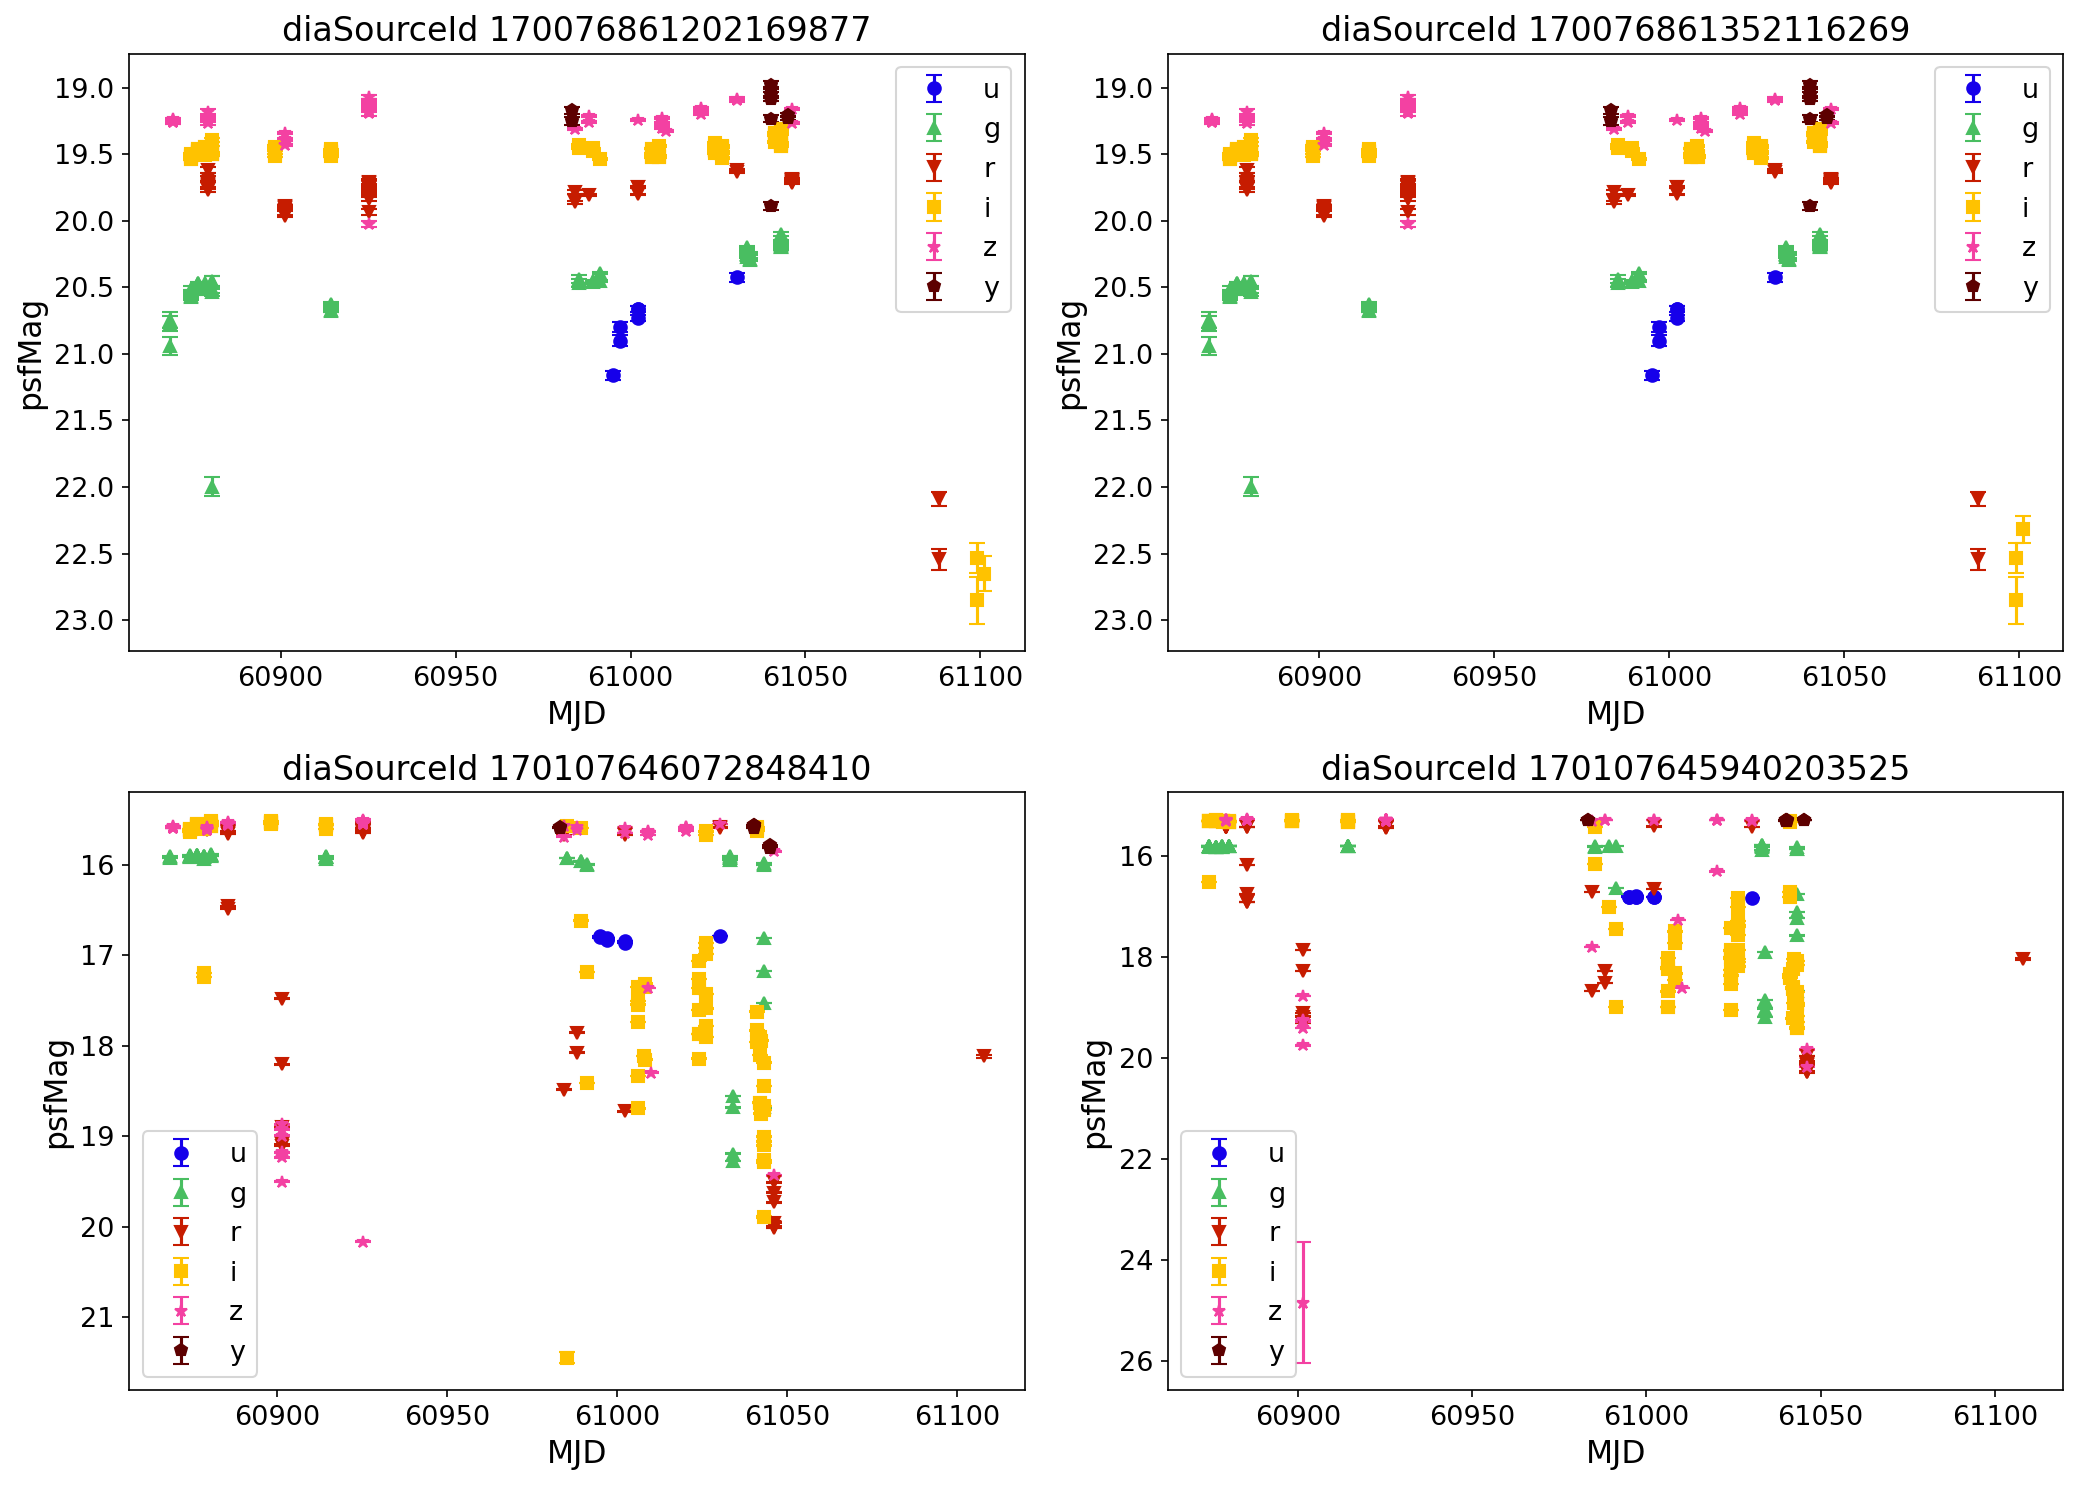

In [13]:
from lsdb_rubin.plot_light_curve import plot_light_curve

filter_colors = {
    "u": "#1600ea",
    "g": "#49be61",
    "r": "#c61c00",
    "i": "#ffc200",
    "z": "#f341a2",
    "y": "#5d0000",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
axes = axes.flatten()

for i, ax in enumerate(axes):
    plt.sca(ax)
    plot_light_curve(
        combined_light_curve(preview, i),
        mag_field="psfMag",
        title=f"diaSourceId {preview['diaSourceId'].iloc[i]}",
        filter_colors=filter_colors,
        plot_kwargs={"capsize": 4},
    )

fig.tight_layout()
plt.show()

## About

**Authors:** Sandro Campos, Konstantin Malanchev, Neven Caplar

**Last updated/verified on:** Jul 22, 2026

If you use `lsdb` for published research, please cite following [instructions](https://docs.lsdb.io/en/stable/citation.html).